In [22]:
import numpy as np

uhi_2015 = np.load("LANDSAT/2015/uhi_2015.npy")
uhi_2020 = np.load("LANDSAT/2020/uhi_2020.npy")
uhi_2025 = np.load("LANDSAT/2025/uhi_2025.npy")

In [23]:
all_data = np.concatenate([
    uhi_2015.flatten(),
    uhi_2020.flatten(),
    uhi_2025.flatten()
])

vmin = np.nanpercentile(all_data, 2)
vmax = np.nanpercentile(all_data, 98)

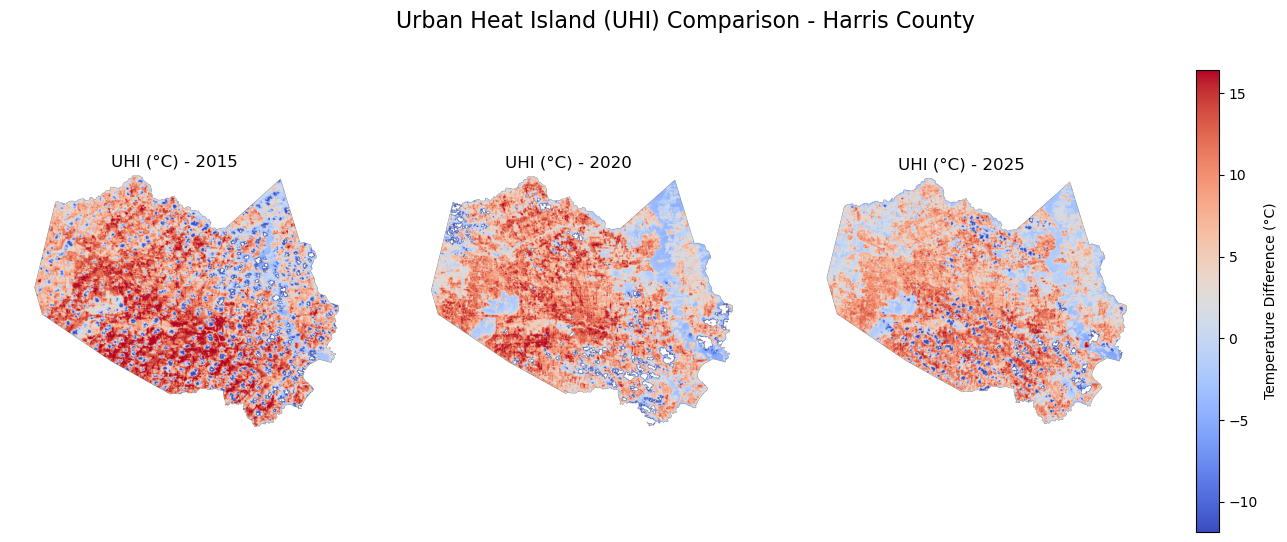

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,6))

years = [2015, 2020, 2025]
data = [uhi_2015, uhi_2020, uhi_2025]

for ax, uhi, year in zip(axes, data, years):
    im = ax.imshow(uhi, cmap="coolwarm", vmin=vmin, vmax=vmax)
    ax.set_title(f"UHI (°C) - {year}")
    ax.axis("off")

fig.colorbar(im, ax=axes.ravel().tolist(), label="Temperature Difference (°C)")
fig.suptitle("Urban Heat Island (UHI) Comparison - Harris County", fontsize=16)
plt.show()

The UHI metric used in this project is calculated with the difference between each pixel’s land surface temperature and the average temperature of vegetated areas. Vegetated areas are identified using NDVI values greater than 0.3. This allows the analysis to compare urban surfaces to a baseline of cooler, vegetated land, effectively measuring the intensity of the urban heat island effect.